In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('titanic_toy.csv')

In [3]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [14]:
null_count = df.isnull()

In [15]:
null_count.mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [16]:
# we can see how much data is not there
# doing train test split 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:3],df['Survived'],test_size=0.25,random_state=12)

In [17]:
x_train.shape 

(668, 3)

In [18]:
x_test.shape

(223, 3)

In [19]:
# now we can put mean and median using pandas 
x_train_mean = x_train['Age'].mean()
x_train_median = x_train['Age'].median()

In [21]:
x_train['filled age with mean'] = x_train['Age'].fillna(x_train_mean)
x_train['filled age with medain'] = x_train['Age'].fillna(x_train_median)

In [22]:
x_train

,Age,Fare,Family,filled age with mean,filled age with medain
613,NaN,7.7500,0,29.317838,28.0
117,29.0,21.0000,1,29.000000,29.0
302,19.0,0.0000,0,19.000000,19.0
167,45.0,27.9000,5,45.000000,45.0
129,45.0,6.9750,0,45.000000,45.0
...,...,...,...,...,...
241,NaN,15.5000,1,29.317838,28.0
253,30.0,16.1000,1,30.000000,30.0
390,36.0,120.0000,3,36.000000,36.0
667,NaN,7.7750,0,29.317838,28.0


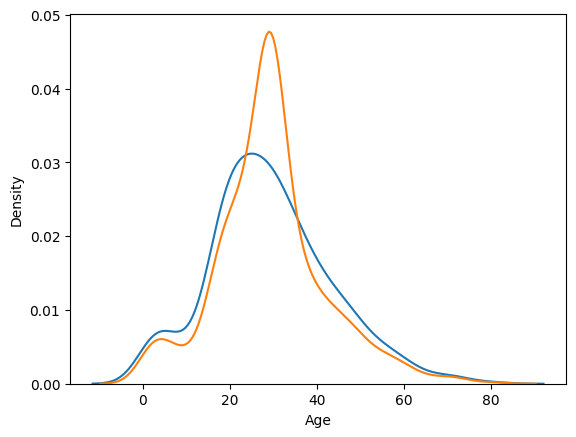

In [28]:
# now ploting graph to see distribution 
sns.kdeplot(x=x_train['Age'])
sns.kdeplot(x=x_train['filled age with mean'])
plt.show()
# we can see before and after of this 

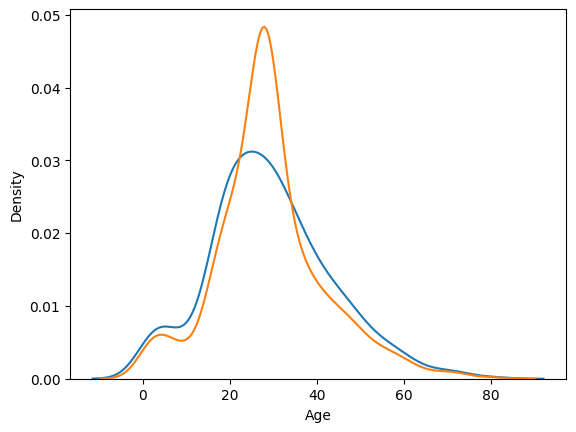

In [29]:
# for median 
sns.kdeplot(x=x_train['Age'])
sns.kdeplot(x=x_train['filled age with medain'])
plt.show()

<Axes: >

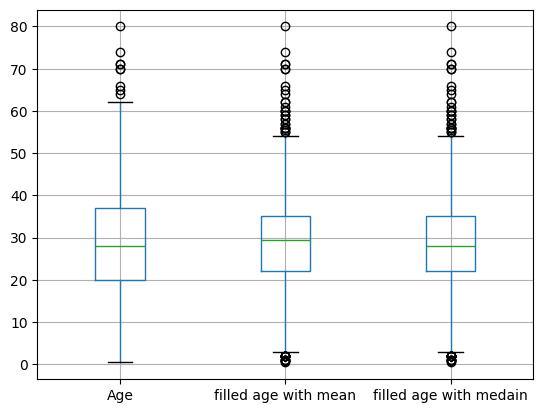

In [40]:
# we can plot bo plot also to see if we got some outliers or not 
x_train[['Age','filled age with mean','filled age with medain']].boxplot()

In [41]:
# we can see due to this we got some outliers 

# Now using sklearn

In [43]:
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:3],df['Survived'],test_size=0.25,random_state=13)

In [44]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [45]:
trf1 = ColumnTransformer(transformers=[
    ('mean impute',SimpleImputer(strategy='mean'),['Age']),
    ('median impute',SimpleImputer(strategy='median'),['Fare'])
],remainder='passthrough')

In [46]:
x_train_trf = trf1.fit_transform(x_train)

In [47]:
x_test_trf = trf1.transform(x_test)

In [50]:
x_train_trf

array([[39.        , 15.2458    ,  0.        ],
       [22.        ,  7.75      ,  0.        ],
       [17.        ,  7.925     ,  6.        ],
       ...,
       [32.        , 56.4958    ,  0.        ],
       [29.79642991, 25.4667    ,  4.        ],
       [45.        ,  8.05      ,  0.        ]], shape=(668, 3))

# Arbitrary value imputation 

In [51]:
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:3],df['Survived'],test_size=0.25,random_state=16)

In [52]:
trf1 = ColumnTransformer(transformers=[
    ('mean impute',SimpleImputer(strategy='constant',fill_value=-1),['Age']),
    ('median impute',SimpleImputer(strategy='constant',fill_value=1),['Fare'])
],remainder='passthrough')

In [53]:
x_train_trf = trf1.fit_transform(x_train)

In [54]:
x_test_trf = trf1.transform(x_test)

In [ ]:
# we can use this to handle missing values as per our need  